In [ ]:
import kagglehub

path = kagglehub.dataset_download("ealaxi/paysim1")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'paysim1' dataset.
Path to dataset files: /kaggle/input/paysim1


In [ ]:
import os
print(os.listdir('/kaggle/input/paysim1'))


['PS_20174392719_1491204439457_log.csv']


In [ ]:
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q


In [ ]:
import cudf
import numpy as np

df = cudf.read_csv('/kaggle/input/paysim1/PS_20174392719_1491204439457_log.csv')
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

# IQR outlier removal
q1, q3 = df['amount'].quantile(0.25), df['amount'].quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df = df[(df['amount'] >= lo) & (df['amount'] <= hi)]

# senders mostly txn once, recipients repeat - use nameDest
counts = df.groupby('nameDest')['nameDest'].transform('count')
df = df[counts >= 3]

df['day'] = df['step'] // 24

feats = df.groupby('nameDest').agg(
    avg_amount=('amount', 'mean'),
    std_amount=('amount', 'std'),
    max_amount=('amount', 'max'),
    txn_count=('amount', 'count'),
    active_days=('day', 'nunique'),
)

feats['max_avg_ratio'] = feats['max_amount'] / feats['avg_amount']
feats['txn_per_active_day'] = feats['txn_count'] / feats['active_days']

# dispersion index
n_bins = 30
acct_min = df.groupby('nameDest')['step'].transform('min')
acct_max = df.groupby('nameDest')['step'].transform('max')
bin_width = (acct_max - acct_min) / n_bins
bin_width = bin_width.where(bin_width > 0, 1)
df['bin'] = ((df['step'] - acct_min) / bin_width).astype('int32').clip(upper=n_bins - 1)

bin_counts = df.groupby(['nameDest', 'bin']).size().reset_index(name='cnt')
bin_stats = bin_counts.groupby('nameDest')['cnt'].agg(['var', 'mean'])
feats['dispersion_index'] = bin_stats['var'] / bin_stats['mean']

fraud_label = df.groupby('nameDest')['isFraud'].max()
feats['is_fraud_linked'] = fraud_label

feats = feats[['avg_amount', 'std_amount', 'max_avg_ratio', 'txn_count',
               'txn_per_active_day', 'dispersion_index', 'is_fraud_linked']]

feats_pd = feats.to_pandas()
feats_pd.to_csv('/content/account_features.csv')
print(feats_pd.shape)
print(feats_pd.isna().sum())
print(feats_pd.describe())


(291994, 7)
avg_amount            0
std_amount            0
max_avg_ratio         0
txn_count             0
txn_per_active_day    0
dispersion_index      6
is_fraud_linked       0
dtype: int64
          avg_amount     std_amount  max_avg_ratio      txn_count  \
count  291994.000000  291994.000000  291994.000000  291994.000000   
mean   180628.821978  122094.050142       2.076961       7.727388   
std     63909.559192   50595.886708       0.532559       5.346093   
min      4002.840000     235.103815       1.003339       3.000000   
25%    136786.071500   86099.540690       1.678904       4.000000   
50%    179945.954643  121826.928219       2.017852       6.000000   
75%    221211.021667  155523.436861       2.408186      10.000000   
max    563294.996667  360692.669878       5.830680      59.000000   

       txn_per_active_day  dispersion_index  is_fraud_linked  
count       291994.000000     291988.000000    291994.000000  
mean             1.467910          0.373644         0.00824

In [ ]:
import pandas as pd

feats = pd.read_csv('/content/account_features.csv', index_col=0)
feats = feats[['avg_amount', 'std_amount', 'max_avg_ratio', 'txn_count',
               'txn_per_active_day', 'dispersion_index', 'is_fraud_linked']]
feats.to_csv('/content/account_features.csv')
print(feats.shape)


(291994, 7)


=== Skewness & Kurtosis ===
avg_amount           skew=0.29  kurtosis=0.39
std_amount           skew=0.26  kurtosis=0.10
max_avg_ratio        skew=0.68  kurtosis=0.60
txn_count            skew=1.81  kurtosis=4.05
txn_per_active_day   skew=2.47  kurtosis=12.17
dispersion_index     skew=7.23  kurtosis=84.20


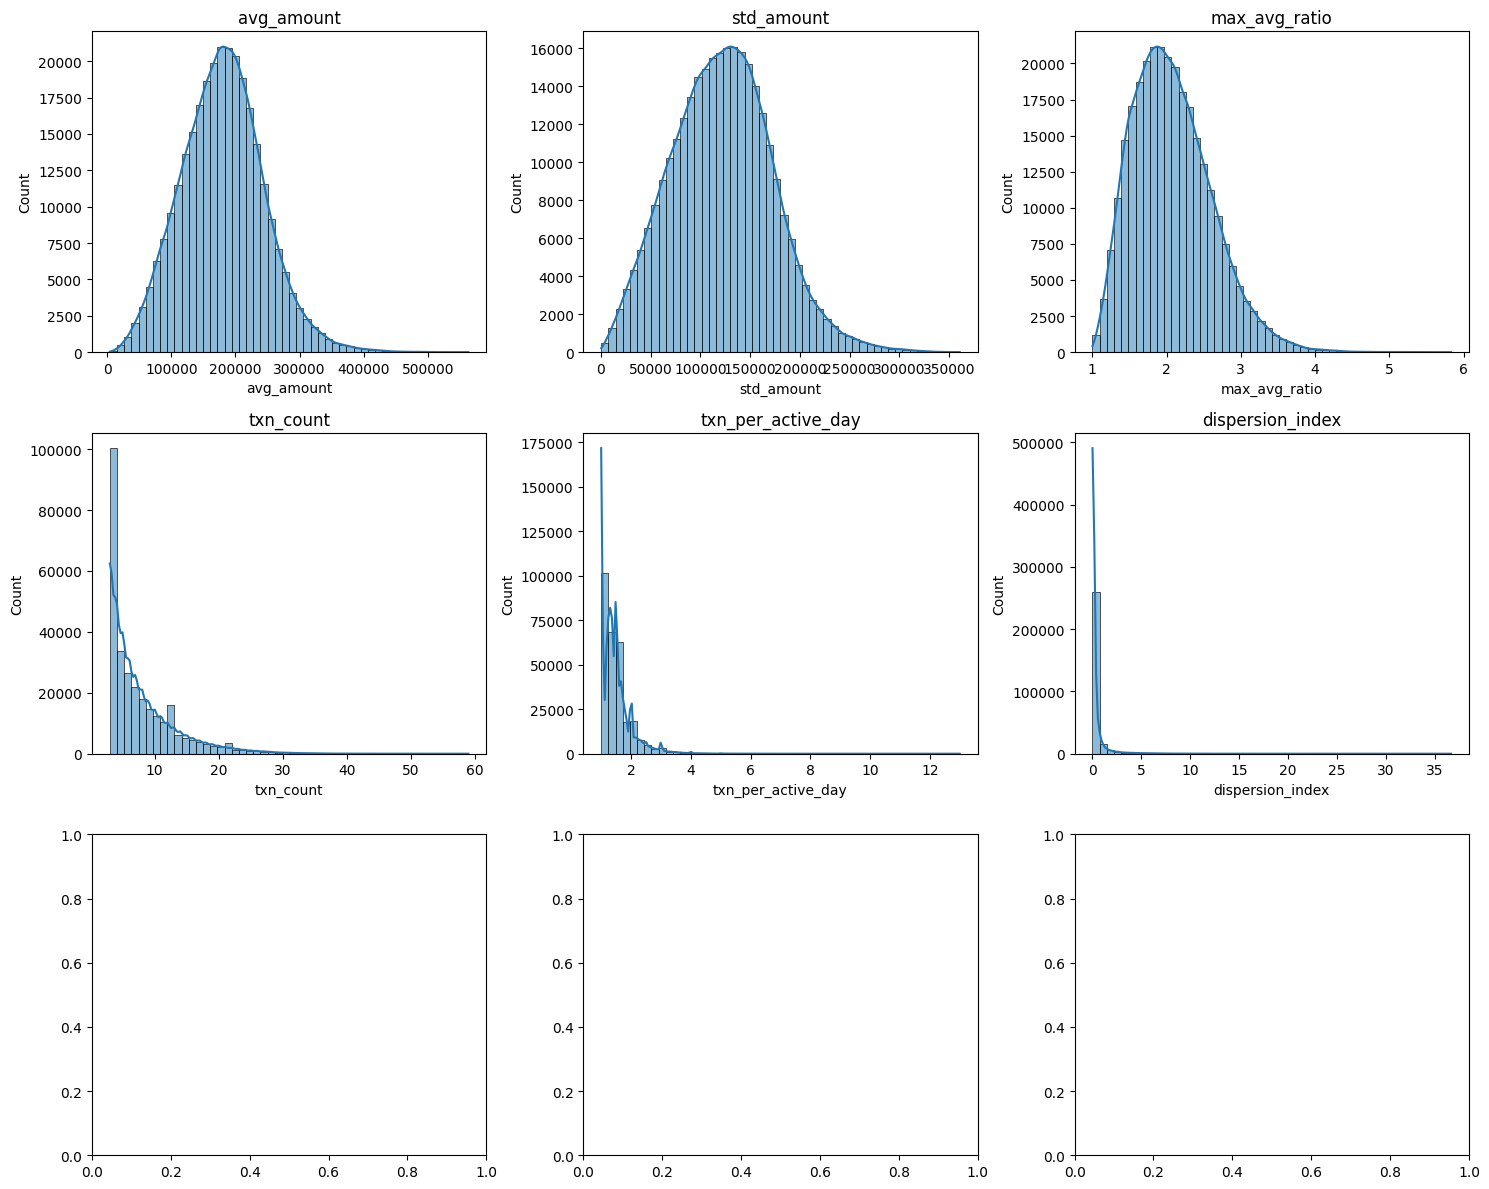

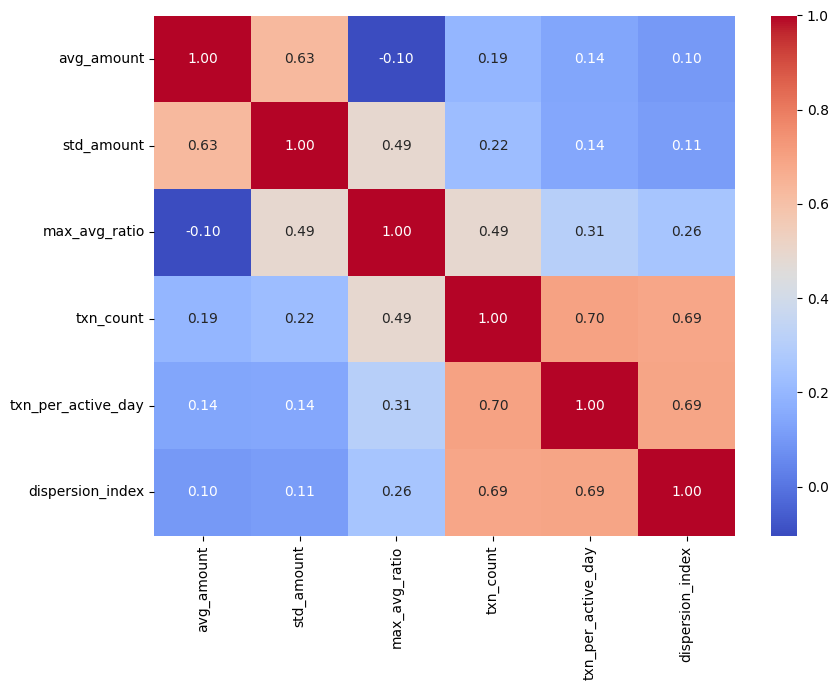

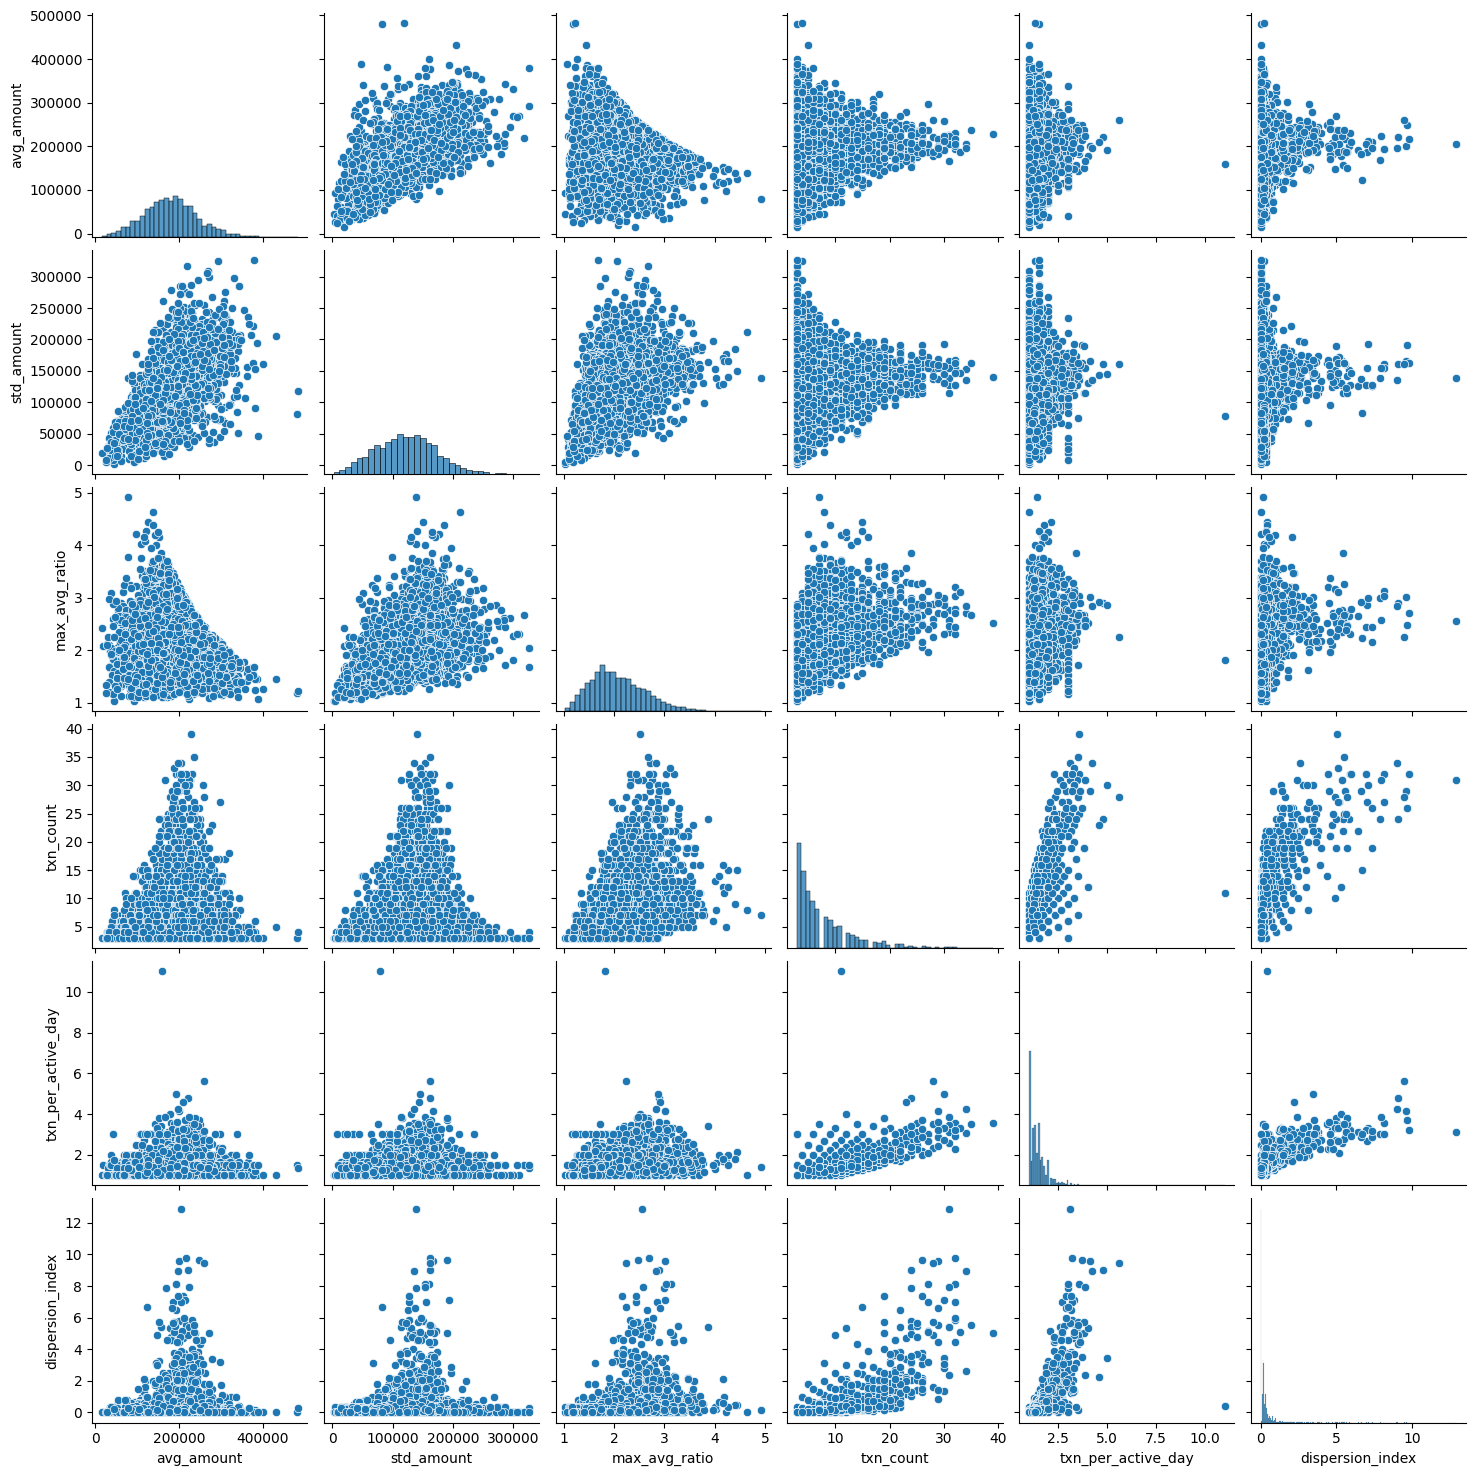

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

feats = pd.read_csv('/content/account_features.csv', index_col=0)
feats = feats.dropna()

FEATURE_COLS = ['avg_amount', 'std_amount', 'max_avg_ratio', 'txn_count',
                'txn_per_active_day', 'dispersion_index']

print("=== Skewness & Kurtosis ===")
for col in FEATURE_COLS:
    print(f"{col:20s} skew={skew(feats[col]):.2f}  kurtosis={kurtosis(feats[col]):.2f}")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, FEATURE_COLS):
    sns.histplot(feats[col], bins=50, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('/content/eda_univariate.png', dpi=100)
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(feats[FEATURE_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.tight_layout()
plt.savefig('/content/eda_corr.png', dpi=100)
plt.show()

sns.pairplot(feats[FEATURE_COLS].sample(3000, random_state=42))
plt.savefig('/content/eda_pairplot.png', dpi=100)
plt.show()


In [ ]:
import pandas as pd
from scipy import stats

feats = pd.read_csv('/content/account_features.csv', index_col=0).dropna()

# Poisson null
d = feats['dispersion_index']
print("Mean dispersion index:", d.mean())
print("% accounts with ratio > 1 (bursty):", (d > 1).mean() * 100)
print("% accounts with ratio > 2 (strongly bursty):", (d > 2).mean() * 100)

t_stat, p_val = stats.ttest_1samp(d, popmean=1)
print(f"\nOne-sample t-test vs Poisson null (mean=1): t={t_stat:.2f}, p={p_val:.4g}")

fraud = feats[feats['is_fraud_linked'] == 1]['dispersion_index']
normal = feats[feats['is_fraud_linked'] == 0]['dispersion_index']
u_stat, p_val2 = stats.mannwhitneyu(fraud, normal, alternative='greater')
print(f"\nFraud-linked mean dispersion: {fraud.mean():.3f}")
print(f"Non-fraud mean dispersion: {normal.mean():.3f}")
print(f"Mann-Whitney U test (fraud > normal): U={u_stat:.0f}, p={p_val2:.4g}")


Mean dispersion index: 0.373643998860454
% accounts with ratio > 1 (bursty): 7.468800087674836
% accounts with ratio > 2 (strongly bursty): 3.772757784566489

One-sample t-test vs Poisson null (mean=1): t=-344.54, p=0

Fraud-linked mean dispersion: 0.566
Non-fraud mean dispersion: 0.372
Mann-Whitney U test (fraud > normal): U=376012455, p=1.604e-12


Explained variance ratio per component:
[0.48336546 0.24204181 0.16298789 0.05663615 0.03994172 0.01502696]

Cumulative variance:
[0.48336546 0.72540727 0.88839516 0.94503131 0.98497304 1.        ]


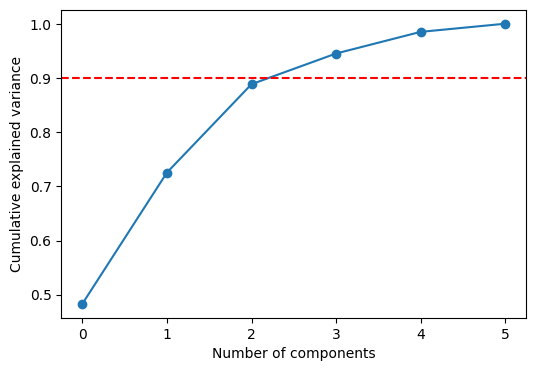


Saved X_pca_3.npy and labels.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

feats = pd.read_csv('/content/account_features.csv', index_col=0).dropna()

FEATURE_COLS = ['avg_amount', 'std_amount', 'max_avg_ratio', 'txn_count',
                'txn_per_active_day', 'dispersion_index']

X = feats[FEATURE_COLS].copy()

for col in ['txn_count', 'txn_per_active_day', 'dispersion_index']:
    X[col] = np.log1p(X[col])

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=X_scaled.shape[1])
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:")
print(pca.explained_variance_ratio_)
print("\nCumulative variance:")
print(np.cumsum(pca.explained_variance_ratio_))

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.9, color='r', linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.savefig('/content/pca_scree.png', dpi=100)
plt.show()

X_pca_3 = X_pca[:, :3]
np.save('/content/X_pca_3.npy', X_pca_3)
feats[['is_fraud_linked']].to_csv('/content/labels.csv')
print("\nSaved X_pca_3.npy and labels.csv")


In [ ]:
import numpy as np
import pandas as pd
from cuml.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

X = np.load('/content/X_pca_3.npy').astype(np.float32)
labels_true = pd.read_csv('/content/labels.csv', index_col=0)['is_fraud_linked'].values

results = {}

km = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km.fit_predict(X)
results['KMeans'] = np.asarray(km_labels)

agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X[:20000])
results['Agglomerative (20k sample)'] = np.asarray(agg_labels)

db = DBSCAN(eps=0.15, min_samples=10)
db_labels = db.fit_predict(X)
results['DBSCAN'] = np.asarray(db_labels)

for name, lbl in results.items():
    n_pts = len(lbl)
    xx = X[:n_pts]
    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    if n_clusters < 2:
        print(f"{name}: only {n_clusters} cluster(s), skipping metrics")
        continue
    sil = silhouette_score(xx, lbl)
    db_score = davies_bouldin_score(xx, lbl)
    print(f"{name}: clusters={n_clusters}  silhouette={sil:.3f}  davies_bouldin={db_score:.3f}")

def fraud_rate_per_cluster(lbl, y):
    d = pd.DataFrame({'cluster': lbl, 'fraud': y})
    return d.groupby('cluster')['fraud'].agg(['mean', 'count'])

print("\n--- K-Means cluster fraud rates ---")
print(fraud_rate_per_cluster(results['KMeans'], labels_true))

print("\n--- DBSCAN cluster fraud rates (-1 = noise/outliers) ---")
print(fraud_rate_per_cluster(results['DBSCAN'], labels_true))


In [ ]:
# eps=0.15 was too tight, redo with 0.30
db = DBSCAN(eps=0.3, min_samples=10)
db_labels = np.asarray(db.fit_predict(X))
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print("clusters:", n_clusters)
sil = silhouette_score(X, db_labels, sample_size=10000, random_state=42)
print(f"silhouette={sil:.3f}")
df_fraud = pd.DataFrame({'cluster': db_labels, 'fraud': labels_true})
print(df_fraud.groupby('cluster')['fraud'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10))


[2026-09-04 14:03:52.827] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8565 -> 7354. Using the larger integer type might result in better performance
clusters: 2
silhouette=0.475
             mean   count
cluster                  
 0       0.008174  290428
-1       0.020632    1551
 1       0.000000       9


In [ ]:
print("=== K-Means ===")
n = len(set(km_labels))
sil = silhouette_score(X, km_labels, sample_size=10000, random_state=42)
db_sc = davies_bouldin_score(X, km_labels)
print(f"clusters={n} silhouette={sil:.3f} davies_bouldin={db_sc:.3f}")
print(pd.DataFrame({'cluster': km_labels, 'fraud': labels_true}).groupby('cluster')['fraud'].agg(['mean','count']))

print("\n=== Agglomerative ===")
Xa = X[:len(agg_labels)]
n = len(set(agg_labels))
sil = silhouette_score(Xa, agg_labels)
db_sc = davies_bouldin_score(Xa, agg_labels)
print(f"clusters={n} silhouette={sil:.3f} davies_bouldin={db_sc:.3f}")
print(pd.DataFrame({'cluster': agg_labels, 'fraud': labels_true[:len(agg_labels)]}).groupby('cluster')['fraud'].agg(['mean','count']))

print("\n=== DBSCAN (eps=0.3) ===")
db = DBSCAN(eps=0.3, min_samples=10)
db_labels = np.asarray(db.fit_predict(X))
n = len(set(db_labels)) - (1 if -1 in db_labels else 0)
sil = silhouette_score(X, db_labels, sample_size=10000, random_state=42)
db_sc = davies_bouldin_score(X, db_labels)
print(f"clusters={n} silhouette={sil:.3f} davies_bouldin={db_sc:.3f}")
print(pd.DataFrame({'cluster': db_labels, 'fraud': labels_true}).groupby('cluster')['fraud'].agg(['mean','count']))


=== K-Means ===
clusters=4 silhouette=0.303 davies_bouldin=1.109
             mean   count
cluster                  
0        0.006319  106985
1        0.012304   24788
2        0.008262   72866
3        0.009422   87349

=== Agglomerative ===
clusters=4 silhouette=0.358 davies_bouldin=0.398
             mean  count
cluster                 
0        0.008451  19997
1        0.000000      1
2        0.000000      1
3        0.000000      1

=== DBSCAN (eps=0.3) ===
[2026-09-04 14:06:05.898] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8565 -> 7354. Using the larger integer type might result in better performance
clusters=2 silhouette=0.475 davies_bouldin=1.707
             mean   count
cluster                  
-1       0.020632    1551
 0       0.008174  290428
 1       0.000000       9


Using cuML (GPU) DBSCAN
Baseline fraud rate: 0.8240%

[2026-09-04 14:13:18.632] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8565 -> 7354. Using the larger integer type might result in better performance
eps=0.15  clusters=116  silhouette=-0.384  noise_size=15050  noise_fraud_rate=1.17%
[2026-09-04 14:13:27.120] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8565 -> 7354. Using the larger integer type might result in better performance
eps=0.25  clusters=4  silhouette=0.218  noise_size=2893  noise_fraud_rate=1.69%
[2026-09-04 14:13:35.644] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8565 -> 7354. Using the larger integer type might result in better performance
eps=0.30  clusters=2  silhouette=0.475  noise_size=1551  noise_fraud_rate=2.06%
[2026-09-04 14:13:44.450] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8565 -> 7354. Using the larger integer type might result in better performanc

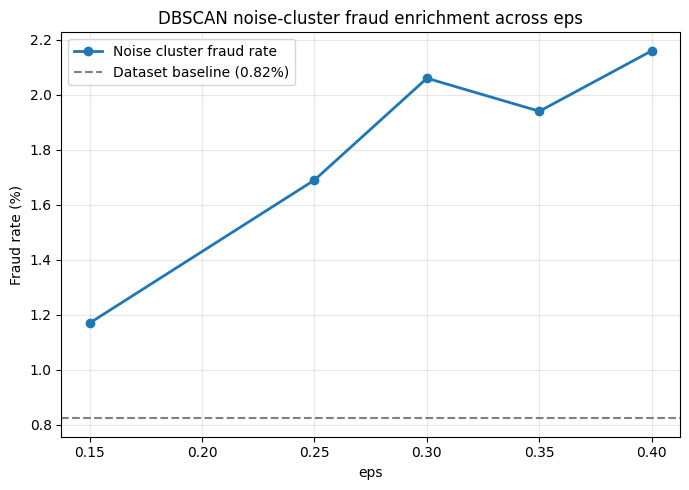

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

X = np.load('/content/X_pca_3.npy').astype(np.float32)
labels_true = pd.read_csv('/content/labels.csv')['is_fraud_linked'].values

try:
    from cuml.cluster import DBSCAN
    print("Using cuML (GPU) DBSCAN")
except ImportError:
    from sklearn.cluster import DBSCAN
    print("cuML not available, using sklearn (CPU) DBSCAN")

BASELINE_FRAUD_RATE = labels_true.mean()
print(f"Baseline fraud rate: {BASELINE_FRAUD_RATE:.4%}\n")

eps_values = [0.15, 0.25, 0.30, 0.35, 0.40]
results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10)
    db_labels = np.asarray(db.fit_predict(X))

    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    sil = silhouette_score(X, db_labels, sample_size=10000, random_state=42)

    noise_mask = db_labels == -1
    noise_size = noise_mask.sum()
    noise_fraud_rate = labels_true[noise_mask].mean() if noise_size > 0 else np.nan

    results.append({
        'eps': eps,
        'clusters': n_clusters,
        'silhouette': round(sil, 3),
        'noise_size': int(noise_size),
        'noise_fraud_rate': round(noise_fraud_rate * 100, 2),
    })
    print(f"eps={eps:.2f}  clusters={n_clusters}  silhouette={sil:.3f}  "
          f"noise_size={noise_size}  noise_fraud_rate={noise_fraud_rate:.2%}")

results_df = pd.DataFrame(results)
results_df.to_csv('/content/eps_sensitivity_sweep.csv', index=False)
print("\nSaved table to eps_sensitivity_sweep.csv")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(results_df['eps'], results_df['noise_fraud_rate'], marker='o', linewidth=2, label='Noise cluster fraud rate')
ax.axhline(BASELINE_FRAUD_RATE * 100, color='gray', linestyle='--', label=f'Dataset baseline ({BASELINE_FRAUD_RATE:.2%})')
ax.set_xlabel('eps')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('DBSCAN noise-cluster fraud enrichment across eps')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('/content/eps_sensitivity_plot.png', dpi=150)
print("Saved plot to eps_sensitivity_plot.png")


In [ ]:
pip install groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 4.6 MB/s eta 0:00:00


In [ ]:
import os; os.environ["GROQ_API_KEY"] = ""


In [ ]:
import os
import json
import pandas as pd
from groq import Groq

client = Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL = "openai/gpt-oss-120b"

FEATURE_COLS = ['avg_amount', 'std_amount', 'max_avg_ratio', 'txn_count',
                'txn_per_active_day', 'dispersion_index']

SYSTEM_PROMPT = """You are a fraud-review assistant for a payments platform.
You are given a recipient account's transaction-pattern features and the
reason a clustering model flagged it as anomalous. You do NOT have access to
raw transaction data or personal information, only these aggregate stats.

You NEVER approve, block, or move money. You only produce a structured risk
assessment for a human reviewer. Be concise and concrete -- reference the
actual feature values in your explanation, don't just restate the trigger reason.

Respond with ONLY valid JSON, no markdown fences, no preamble, in this exact shape:
{
  "risk_level": "low" | "medium" | "high",
  "explanation": "1-3 plain-language sentences, referencing specific feature values",
  "recommended_action": "monitor" | "alert" | "escalate" | "hold_for_review",
  "confidence": "low" | "medium" | "high"
}
"""


def build_user_prompt(account_id, features: dict, trigger_reason: str) -> str:
    feat_lines = "\n".join(f"- {k}: {v:.4f}" for k, v in features.items())
    return f"""Account ID: {account_id}
Trigger reason: {trigger_reason}

Features:
{feat_lines}

Assess this account's fraud risk."""


def assess_account(account_id, features: dict, trigger_reason: str) -> dict:
    user_prompt = build_user_prompt(account_id, features, trigger_reason)

    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_prompt},
            ],
            temperature=0.2,
            max_tokens=1000,
        )
        raw = resp.choices[0].message.content.strip()
        raw = raw.removeprefix("```json").removeprefix("```").removesuffix("```").strip()
        result = json.loads(raw)
    except (json.JSONDecodeError, Exception) as e:
        # this was silently eating errors before, keeping it visible now
        result = {
            "risk_level": "unknown",
            "explanation": f"Agent call failed or returned invalid JSON: {e}",
            "recommended_action": "hold_for_review",
            "confidence": "low",
        }

    result["account_id"] = account_id
    result["trigger_reason"] = trigger_reason
    return result


def run_agent_on_flagged(feats_df: pd.DataFrame, db_labels, top_n: int = 20) -> pd.DataFrame:
    feats_df = feats_df.reset_index().rename(columns={feats_df.index.name or 'index': 'account_id'})
    flagged = feats_df[db_labels == -1].copy()
    flagged = flagged.sort_values('dispersion_index', ascending=False).head(top_n)

    records = []
    for _, row in flagged.iterrows():
        features = {c: float(row[c]) for c in FEATURE_COLS}
        trigger_reason = "Flagged as outlier by DBSCAN (eps=0.3) on PCA-reduced behavioral features"
        result = assess_account(row['account_id'], features, trigger_reason)
        records.append(result)
        print(f"{row['account_id']}: {result['risk_level']} -> {result['recommended_action']}")

    return pd.DataFrame(records)


if __name__ == "__main__":
    feats = pd.read_csv('/content/account_features.csv', index_col=0).dropna()
    labels_true = pd.read_csv('/content/labels.csv')

    audit_df = run_agent_on_flagged(feats, db_labels, top_n=20)
    audit_df.to_csv('/content/agent_audit_trail.csv', index=False)
    print("\nSaved audit trail to agent_audit_trail.csv")


C2083562754: high -> hold_for_review
C306206744: high -> escalate
C985934102: high -> hold_for_review
C1286084959: high -> escalate
C2006081398: high -> hold_for_review
C977993101: high -> escalate
C1360767589: high -> hold_for_review
C1728766751: high -> escalate
C248609774: medium -> alert
C747464370: high -> escalate
C998351292: high -> hold_for_review
C803116137: high -> hold_for_review
C68113386: high -> escalate
C1899073220: high -> hold_for_review
C97730845: high -> hold_for_review
C979719862: medium -> alert
C1303868418: high -> escalate
C818570949: medium -> alert
C453211571: high -> hold_for_review
C1313534832: high -> escalate

Saved audit trail to agent_audit_trail.csv


In [ ]:
def run_agent_on_flagged(feats_df, db_labels, top_n=100, delay=2.0):
    feats_df = feats_df.reset_index().rename(columns={feats_df.index.name or 'index': 'account_id'})
    flagged = feats_df[db_labels == -1].copy()
    flagged = flagged.sort_values('dispersion_index', ascending=False).head(top_n)

    records = []
    for _, row in flagged.iterrows():
        features = {c: float(row[c]) for c in FEATURE_COLS}
        trigger_reason = "Flagged as outlier by DBSCAN (eps=0.3) on PCA-reduced behavioral features"
        result = assess_account(row['account_id'], features, trigger_reason)
        records.append(result)
        print(f"{row['account_id']}: {result['risk_level']} -> {result['recommended_action']}")
        time.sleep(delay)
    return pd.DataFrame(records)

audit_df = run_agent_on_flagged(feats, db_labels, top_n=100, delay=2.0)
audit_df.to_csv('/content/agent_audit_trail_100.csv', index=False)


C2083562754: high -> escalate
C306206744: high -> hold_for_review
C985934102: high -> escalate
C1286084959: high -> alert
C2006081398: high -> escalate
C977993101: high -> hold_for_review
C1360767589: high -> hold_for_review
C1728766751: high -> hold_for_review
C248609774: high -> alert
C747464370: high -> escalate
C998351292: high -> hold_for_review
C803116137: medium -> alert
C68113386: high -> hold_for_review
C1899073220: high -> escalate
C97730845: medium -> alert
C979719862: high -> hold_for_review
C1303868418: high -> hold_for_review
C818570949: high -> escalate
C453211571: high -> hold_for_review
C1313534832: high -> escalate
C1028574311: high -> hold_for_review
C1504109395: high -> escalate
C1325038895: high -> escalate
C1570256460: high -> escalate
C539486713: medium -> hold_for_review
C952219856: high -> hold_for_review
C1234776885: high -> hold_for_review
C794295331: high -> escalate
C1379289710: high -> hold_for_review
C1235151206: high -> escalate
C481402298: high -> hold_

In [ ]:
merged = audit_df.merge(labels_true, on='account_id', how='left')
print(merged.groupby('risk_level')['is_fraud_linked'].agg(['mean', 'count']))


                mean  count
risk_level                 
high        0.032258     93
medium      0.142857      7
